# Feature-conditioned MLE: one-run diagnostics

This notebook diagnoses the atom-count MLE on one generated run, without MCMC. It compares the ordinary count-only likelihood with progressively richer image-summary-conditioned models:

1. differential phase: $\delta\psi_i=\beta_\phi^T[s_{0,i},s_{100,i}]$;
2. local offsets: $A_{z,i}=A_z+\beta_{A,z}^Ts_{z,i}$;
3. local contrasts: $C_{z,i}=C_z\exp(\beta_{C,z}^Ts_{z,i})$.

The emphasis is diagnostic rather than merely obtaining one answer: feature conditioning, model complexity, optimizer status, physical probability margins, nuisance time series, likelihood slices, and residuals relative to shot noise are all made visible. Residual plots use the known simulated common phase, so they are **truth-assisted generated-data diagnostics**, not quantities available in a real experiment.


In [43]:
from pathlib import Path
import importlib.util
import sys
import time
import warnings

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if not (REPO / 'helpers').is_dir():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'helpers'))

from helpers import ImageShotDataset
from likelihood import LikelihoodEvaluator, FeatureConditionedLikelihoodEvaluator
from fitting import fit_from_datasets, fit_feature_conditioned_from_datasets

# Reuse exactly the artifact-selection code used by the batch CLI.
_spec = importlib.util.spec_from_file_location(
    'fit_mle_distributions_cli', REPO / 'python-scripts' / 'fit_mle_distributions.py'
)
_cli = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_cli)
load_feature_artifacts = _cli.load_feature_artifacts
select_run_features = _cli.select_run_features

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)


## Configuration

Choose summaries independently at each site. PCs are appended after named summaries. `MODELS_TO_REFIT` is the main runtime switch: leave it empty to reuse matching rows from existing batch result files, or list any subset of the model names to rerun on this one experiment. A first interactive pass with `FAST=True` and `NTHETA=512` is useful for diagnosis; use adaptive quadrature (`NTHETA=None`) and `FAST=False` for the final estimate.


In [44]:
DATASET_DIR = REPO / 'data' / (
    'R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_'
    'sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_'
    'phi0random_sig_A0.100_f0.3000'
)
RUN_INDEX = 0

FEATURE_DIR_Z0 = REPO / 'results' / '2d-shot-features-z0'
FEATURE_DIR_Z100 = REPO / 'results' / '2d-shot-features-z100'
FEATURES_Z0 = ['mean_x', 'std_x', 'mean_y', 'std_y']
FEATURES_Z100 = ['mean_x', 'std_x', 'mean_y', 'std_y']
N_PCS_Z0 = 0
N_PCS_Z100 = 0
PCA_PATH_Z0 = None
PCA_PATH_Z100 = None

FREQUENCY = 0.3
USE_GPU = False
FAST = True
NTHETA = 512
BETA_PHI_PRIOR_STD = 0.3
BETA_A_PRIOR_STD = 0.03
BETA_C_PRIOR_STD = 0.3

MODEL_SPECS = {
    'count-only': None,
    'phase': ('phase',),
    'phase+offset': ('phase', 'offset'),
    'phase+contrast': ('phase', 'contrast'),
    'full': ('phase', 'offset', 'contrast'),
}

# Examples: ['phase'] for the minimal new model, or list(MODEL_SPECS) for all.
MODELS_TO_REFIT = ['full']

# Saved rows are used only when their selected features/nuisance blocks match.
SAVED_RESULTS = {
    'count-only': REPO / 'results' / 'mle_count_only.pkl',
    'full': REPO / 'results' / 'mle_feature_full.pkl',
}


## Load one generated experiment


In [45]:
run_name = f'run_{RUN_INDEX:03d}'
run_dir = DATASET_DIR / run_name
Z0 = ImageShotDataset(run_dir / 'Z0' / 'data_IMG.h5')
Z100 = ImageShotDataset(run_dir / 'Z100' / 'data_IMG.h5')

with h5py.File(Z0.path) as h5:
    SIGNAL_AMP = float(h5.attrs['signal_amp'])
    SIGNAL_FREQ = float(h5.attrs['signal_freq'])
    SIGNAL_PHASE = float(h5.attrs['signal_phase'])

counts_z0 = Z0.state_counts()
counts_z100 = Z100.state_counts()
n0 = counts_z0[0].to_numpy(float)
n100 = counts_z100[0].to_numpy(float)
N0 = counts_z0.sum(axis=1).to_numpy(float)
N100 = counts_z100.sum(axis=1).to_numpy(float)
gf0 = n0 / N0
gf100 = n100 / N100
t = np.arange(Z0.n_shots, dtype=float)

print(f'{run_name}: {Z0.n_shots} shots')
print(f'detected atoms/shot: Z0={N0.mean():,.0f}, Z100={N100.mean():,.0f}')
print(f'injected signal: amplitude={SIGNAL_AMP:.6f} rad, phase={SIGNAL_PHASE:.6f} rad, frequency={SIGNAL_FREQ:.6f}')
print(f'fit frequency: {FREQUENCY:.6f}; quadrature: {NTHETA or "adaptive"}; GPU requested: {USE_GPU}')


run_000: 50 shots
detected atoms/shot: Z0=582,884, Z100=445,280
injected signal: amplitude=0.100000 rad, phase=0.500000 rad, frequency=0.300000
fit frequency: 0.300000; quadrature: 512; GPU requested: False


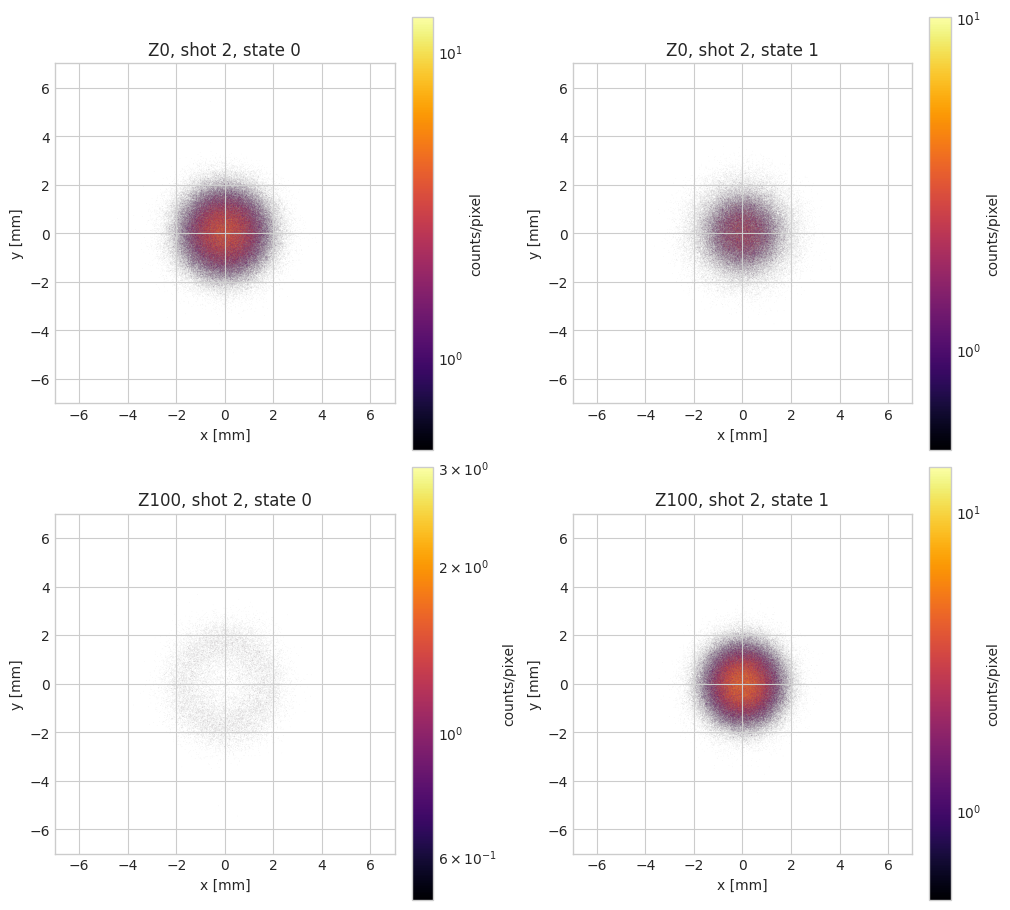

In [46]:
SHOT_TO_VIEW = min(2, Z0.n_shots - 1)
lim = Z0.half_range * 1e3
extent = [-lim, lim, -lim, lim]
fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
for row, (dataset, site) in enumerate([(Z0, 'Z0'), (Z100, 'Z100')]):
    image = dataset[SHOT_TO_VIEW]
    for col, state in enumerate((0, 1)):
        ax = axes[row, col]
        im = ax.imshow(image[state].T, origin='lower', extent=extent,
                       norm=LogNorm(vmin=0.5), cmap='inferno', aspect='equal')
        fig.colorbar(im, ax=ax, label='counts/pixel')
        ax.set(title=f'{site}, shot {SHOT_TO_VIEW}, state {state}', xlabel='x [mm]', ylabel='y [mm]')


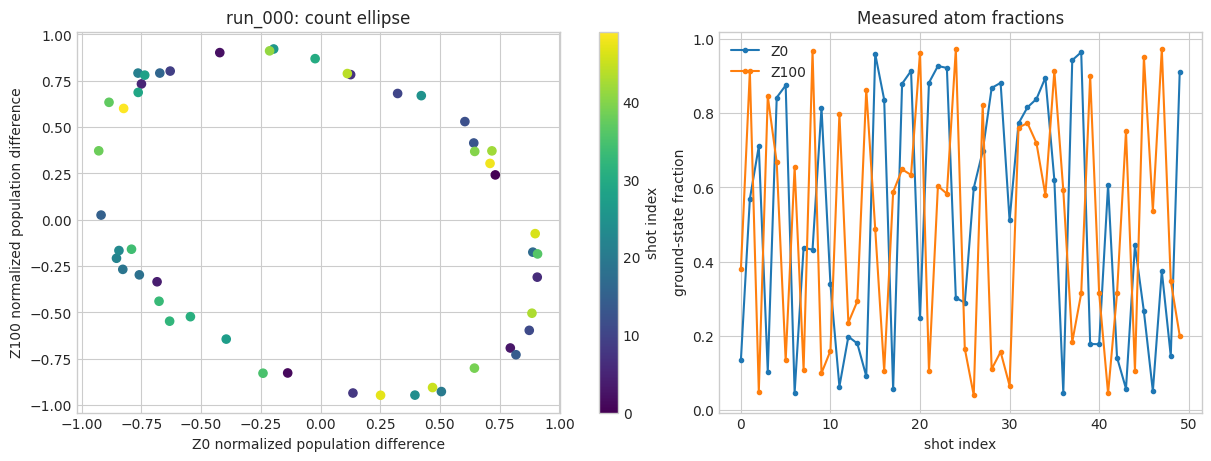

In [47]:
diff0 = 1 - 2 * gf0
diff100 = 1 - 2 * gf100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
sc = axes[0].scatter(diff0, diff100, c=t, cmap='viridis', s=35)
fig.colorbar(sc, ax=axes[0], label='shot index')
axes[0].set(xlabel='Z0 normalized population difference', ylabel='Z100 normalized population difference',
            title=f'{run_name}: count ellipse')
axes[1].plot(t, gf0, 'o-', ms=3, label='Z0')
axes[1].plot(t, gf100, 'o-', ms=3, label='Z100')
axes[1].set(xlabel='shot index', ylabel='ground-state fraction', title='Measured atom fractions')
axes[1].legend()


## Load and inspect selected image summaries

Standardization uses the mean and standard deviation over the complete artifact, exactly as in the batch fitter. This avoids redefining a coefficient scale independently for every 50-shot run. Strong correlations here flag weakly identifiable beta directions before optimization begins.


In [48]:
artifact_z0 = load_feature_artifacts(FEATURE_DIR_Z0, FEATURES_Z0, N_PCS_Z0, PCA_PATH_Z0)
artifact_z100 = load_feature_artifacts(FEATURE_DIR_Z100, FEATURES_Z100, N_PCS_Z100, PCA_PATH_Z100)
features_z0 = select_run_features(artifact_z0, RUN_INDEX, Z0.n_shots)
features_z100 = select_run_features(artifact_z100, RUN_INDEX, Z100.n_shots)
names_z0 = tuple(artifact_z0['feature_names'])
names_z100 = tuple(artifact_z100['feature_names'])
s0 = (features_z0 - artifact_z0['feature_mean']) / artifact_z0['feature_scale']
s100 = (features_z100 - artifact_z100['feature_mean']) / artifact_z100['feature_scale']

feature_frame = pd.DataFrame({
    **{f'Z0:{name}': s0[:, j] for j, name in enumerate(names_z0)},
    **{f'Z100:{name}': s100[:, j] for j, name in enumerate(names_z100)},
})
display(pd.DataFrame({
    'site': ['Z0'] * len(names_z0) + ['Z100'] * len(names_z100),
    'feature': list(names_z0) + list(names_z100),
    'artifact_mean': np.r_[artifact_z0['feature_mean'], artifact_z100['feature_mean']],
    'artifact_scale': np.r_[artifact_z0['feature_scale'], artifact_z100['feature_scale']],
    'run_standardized_mean': np.r_[s0.mean(0), s100.mean(0)],
    'run_standardized_std': np.r_[s0.std(0), s100.std(0)],
}))


,site,feature,artifact_mean,artifact_scale,run_standardized_mean,run_standardized_std
0,Z0,mean_x,-2.254080e-07,0.000022,0.089478,1.043994
1,Z0,std_x,8.815004e-04,0.000015,-0.079076,0.988234
2,Z0,mean_y,3.460539e-07,0.000022,-0.013547,1.003423
3,Z0,std_y,8.817133e-04,0.000015,-0.013054,0.820607
4,Z100,mean_x,-8.062001e-07,0.000020,0.007709,0.933302
5,Z100,std_x,8.439056e-04,0.000013,0.013308,1.179730
6,Z100,mean_y,3.305651e-07,0.000020,0.125917,1.110623
7,Z100,std_y,8.439231e-04,0.000013,0.139721,1.095683


,Z0:mean_x,Z0:std_x,Z0:mean_y,Z0:std_y,Z100:mean_x,Z100:std_x,Z100:mean_y,Z100:std_y
Z0:mean_x,1.000,0.022,0.120,0.041,0.128,0.087,0.237,-0.064
Z0:std_x,0.022,1.000,-0.365,-0.279,0.025,0.117,0.020,0.109
Z0:mean_y,0.120,-0.365,1.000,0.186,-0.163,-0.138,-0.149,0.097
Z0:std_y,0.041,-0.279,0.186,1.000,0.141,-0.029,-0.111,-0.008
Z100:mean_x,0.128,0.025,-0.163,0.141,1.000,-0.236,0.128,0.044
Z100:std_x,0.087,0.117,-0.138,-0.029,-0.236,1.000,-0.011,-0.022
Z100:mean_y,0.237,0.020,-0.149,-0.111,0.128,-0.011,1.000,-0.110
Z100:std_y,-0.064,0.109,0.097,-0.008,0.044,-0.022,-0.110,1.000


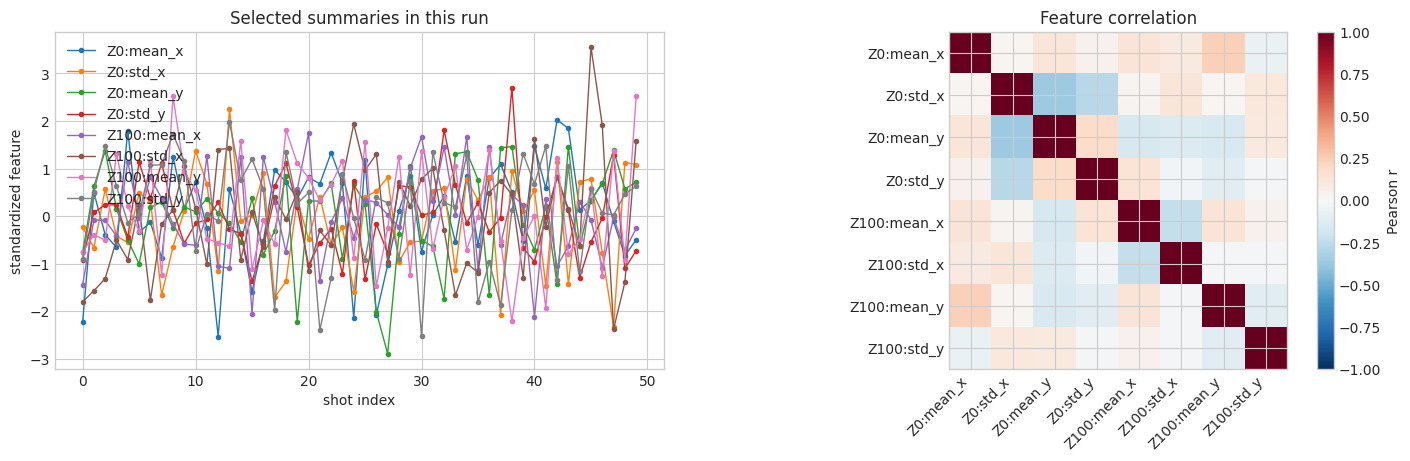

In [49]:
nfeat = feature_frame.shape[1]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
feature_frame.plot(ax=axes[0], marker='.', lw=1)
axes[0].set(xlabel='shot index', ylabel='standardized feature', title='Selected summaries in this run')
corr = feature_frame.corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_xticks(range(nfeat), corr.columns, rotation=45, ha='right')
axes[1].set_yticks(range(nfeat), corr.columns)
axes[1].set_title('Feature correlation')
fig.colorbar(im, ax=axes[1], label='Pearson r')
display(corr.round(3))


## Fit or load nested likelihoods

The models are nested, so compare them in order. `converged=False` is SciPy's stopping flag, not proof that the estimate is bad. Compare the objective, science parameters, physical margins, and nearby likelihood slices before deciding. Conversely, a nominally converged fit can still be poorly identified.


In [50]:
def expected_feature_names():
    return names_z0, names_z100

def load_saved_result(model_name, path):
    if not path.is_file():
        return None
    frame = pd.read_pickle(path)
    if RUN_INDEX >= len(frame):
        return None
    row = frame.iloc[RUN_INDEX].copy()
    nuisance = MODEL_SPECS[model_name]
    if nuisance is None:
        return row
    if tuple(row.get('feature_names_z0', ())) != names_z0:
        return None
    if tuple(row.get('feature_names_z100', ())) != names_z100:
        return None
    if tuple(row.get('feature_nuisance', ())) != tuple(nuisance):
        return None
    return row

fit_rows = {}
fit_times = {}
for model_name, path in SAVED_RESULTS.items():
    row = load_saved_result(model_name, path)
    if row is not None:
        fit_rows[model_name] = row
        fit_times[model_name] = np.nan
        print(f'loaded {model_name!r} from {path.name}')

for model_name in MODELS_TO_REFIT:
    if model_name not in MODEL_SPECS:
        raise KeyError(f'Unknown model {model_name!r}; choose from {tuple(MODEL_SPECS)}')
    start = time.perf_counter()
    nuisance = MODEL_SPECS[model_name]
    if nuisance is None:
        result = fit_from_datasets(
            Z0, Z100, f=FREQUENCY, use_gpu=USE_GPU, ntheta=NTHETA, fast=FAST
        )
    else:
        result = fit_feature_conditioned_from_datasets(
            Z0, Z100, features_z0, features_z100,
            f=FREQUENCY,
            feature_names_z0=names_z0,
            feature_names_z100=names_z100,
            feature_nuisance=nuisance,
            use_gpu=USE_GPU,
            ntheta=NTHETA,
            beta_phi_prior_std=BETA_PHI_PRIOR_STD,
            beta_A_prior_std=BETA_A_PRIOR_STD,
            beta_C_prior_std=BETA_C_PRIOR_STD,
            feature_mean_z0=artifact_z0['feature_mean'],
            feature_scale_z0=artifact_z0['feature_scale'],
            feature_mean_z100=artifact_z100['feature_mean'],
            feature_scale_z100=artifact_z100['feature_scale'],
            fast=FAST,
        )
    fit_rows[model_name] = pd.Series(vars(result))
    fit_times[model_name] = time.perf_counter() - start
    print(f'fit {model_name!r} in {fit_times[model_name]:.1f}s; converged={result.converged}')

if not fit_rows:
    raise RuntimeError('No matching saved fit was found. Add at least one model to MODELS_TO_REFIT.')
missing = [name for name in MODEL_SPECS if name not in fit_rows]
if missing:
    print('Not currently available:', missing)
    print('Add any of these names to MODELS_TO_REFIT for the nested comparison.')


loaded 'count-only' from mle_count_only.pkl
fit 'full' in 134.8s; converged=False
Not currently available: ['phase', 'phase+offset', 'phase+contrast']
Add any of these names to MODELS_TO_REFIT for the nested comparison.


,parameters,converged,amplitude,amplitude error,phase,phase error,logL,beta penalty,log posterior,elapsed [s]
model,,,,,,,,,,
count-only,7,True,0.100503,0.000503,0.505625,0.005625,-2.300669e+07,0.00000,-2.300669e+07,NaN
full,31,False,0.100866,0.000866,0.480404,-0.019596,-2.300660e+07,0.00163,-2.300660e+07,134.842724


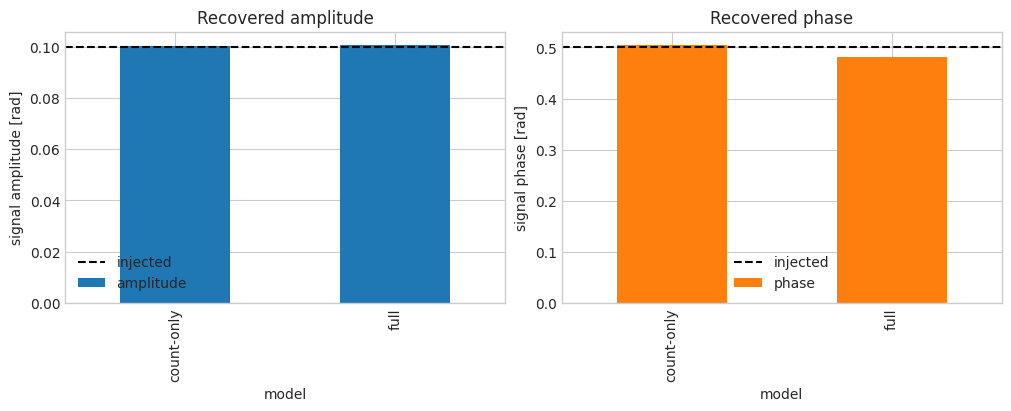

In [51]:
def parameter_count(model_name):
    nuisance = MODEL_SPECS[model_name]
    if nuisance is None:
        return 7
    count = 7
    if 'phase' in nuisance:
        count += len(names_z0) + len(names_z100)
    if 'offset' in nuisance:
        count += len(names_z0) + len(names_z100)
    if 'contrast' in nuisance:
        count += len(names_z0) + len(names_z100)
    return count

summary_rows = []
for name in MODEL_SPECS:
    if name not in fit_rows:
        continue
    row = fit_rows[name]
    phase_error = np.arctan2(np.sin(float(row['phase']) - SIGNAL_PHASE),
                             np.cos(float(row['phase']) - SIGNAL_PHASE))
    summary_rows.append({
        'model': name,
        'parameters': parameter_count(name),
        'converged': bool(row['converged']),
        'amplitude': float(row['amp']),
        'amplitude error': float(row['amp']) - SIGNAL_AMP,
        'phase': float(row['phase']),
        'phase error': phase_error,
        'logL': float(row['logL']),
        'beta penalty': float(row.get('beta_penalty', 0.0)),
        'log posterior': (
            float(row.get('log_posterior', np.nan))
            if np.isfinite(float(row.get('log_posterior', np.nan)))
            else float(row['logL'])
        ),
        'elapsed [s]': fit_times.get(name, np.nan),
    })
fit_summary = pd.DataFrame(summary_rows).set_index('model')
display(fit_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
fit_summary['amplitude'].plot.bar(ax=axes[0], color='C0')
axes[0].axhline(SIGNAL_AMP, color='k', ls='--', label='injected')
axes[0].set(ylabel='signal amplitude [rad]', title='Recovered amplitude')
axes[0].legend()
fit_summary['phase'].plot.bar(ax=axes[1], color='C1')
axes[1].axhline(SIGNAL_PHASE, color='k', ls='--', label='injected')
axes[1].set(ylabel='signal phase [rad]', title='Recovered phase')
axes[1].legend()


## Reconstruct feature-conditioned nuisance terms

These are the quantities the optimizer is asking the image summaries to explain. The physical margin is the shortest distance of either fringe endpoint, $A_i\pm C_i/2$, from probability 0 or 1. A very small or negative margin means the hard invalid-probability boundary is shaping the optimization.


In [52]:
def beta(row, key, size):
    value = row.get(key, ())
    value = np.asarray(value if value is not None else (), dtype=float)
    return value if value.size == size else np.zeros(size)

def reconstruct(row, model_name):
    nuisance = MODEL_SPECS[model_name] or ()
    bphi = beta(row, 'beta_phi', s0.shape[1] + s100.shape[1])
    bA0 = beta(row, 'beta_A1', s0.shape[1])
    bA100 = beta(row, 'beta_A2', s100.shape[1])
    bC0 = beta(row, 'beta_C1', s0.shape[1])
    bC100 = beta(row, 'beta_C2', s100.shape[1])
    phase_features = np.column_stack([s0, s100])
    dpsi = phase_features @ bphi if 'phase' in nuisance else np.zeros(len(t))
    A0_i = float(row['A1']) + (s0 @ bA0 if 'offset' in nuisance else 0.0)
    A100_i = float(row['A2']) + (s100 @ bA100 if 'offset' in nuisance else 0.0)
    C0_i = float(row['C1']) * np.exp(s0 @ bC0 if 'contrast' in nuisance else 0.0)
    C100_i = float(row['C2']) * np.exp(s100 @ bC100 if 'contrast' in nuisance else 0.0)
    A0_i = np.broadcast_to(A0_i, len(t)).astype(float)
    A100_i = np.broadcast_to(A100_i, len(t)).astype(float)
    C0_i = np.broadcast_to(C0_i, len(t)).astype(float)
    C100_i = np.broadcast_to(C100_i, len(t)).astype(float)
    dphi_signal = (float(row['phi0']) + float(row['As']) * np.sin(2*np.pi*FREQUENCY*t)
                   + float(row['Ac']) * np.cos(2*np.pi*FREQUENCY*t))
    margin0 = np.minimum(A0_i - C0_i/2, 1 - A0_i - C0_i/2)
    margin100 = np.minimum(A100_i - C100_i/2, 1 - A100_i - C100_i/2)
    return dict(dpsi=dpsi, A0=A0_i, A100=A100_i, C0=C0_i, C100=C100_i,
                dphi_signal=dphi_signal, margin0=margin0, margin100=margin100)

nuisance_rows = {}
for name, row in fit_rows.items():
    terms = reconstruct(row, name)
    nuisance_rows[name] = {
        'min physical margin Z0': terms['margin0'].min(),
        'min physical margin Z100': terms['margin100'].min(),
        'std dpsi [rad]': terms['dpsi'].std(),
        'range A0': np.ptp(terms['A0']),
        'range A100': np.ptp(terms['A100']),
        'range C0': np.ptp(terms['C0']),
        'range C100': np.ptp(terms['C100']),
    }
display(pd.DataFrame(nuisance_rows).T)


,min physical margin Z0,min physical margin Z100,std dpsi [rad],range A0,range A100,range C0,range C100
count-only,0.030292,0.025632,0.000000,0.000000,0.000000,0.000000,0.000000
full,0.024069,0.022374,0.005954,0.004435,0.006179,0.019145,0.013639


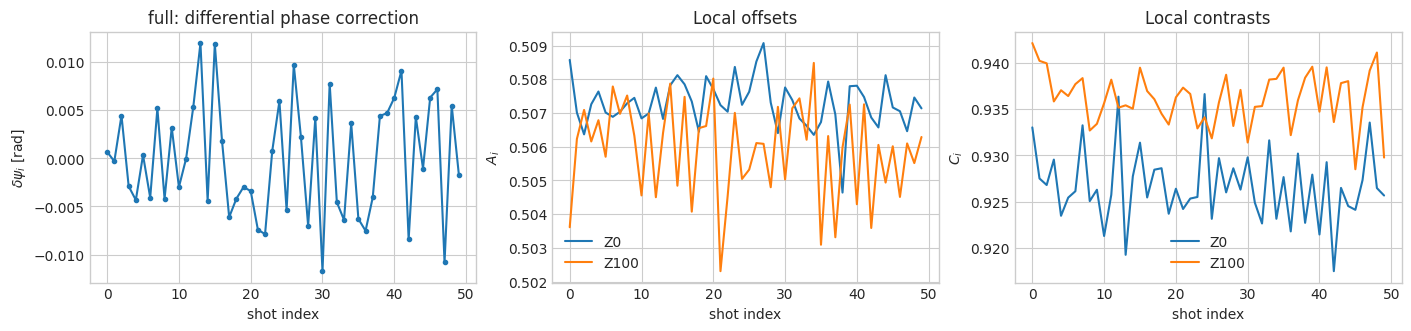

In [53]:
feature_models = [name for name in fit_rows if MODEL_SPECS[name] is not None]
if feature_models:
    fig, axes = plt.subplots(len(feature_models), 3, figsize=(14, 3.2*len(feature_models)),
                             squeeze=False, constrained_layout=True)
    for row_idx, name in enumerate(feature_models):
        terms = reconstruct(fit_rows[name], name)
        axes[row_idx, 0].plot(t, terms['dpsi'], 'o-', ms=3)
        axes[row_idx, 0].set(ylabel=r'$\delta\psi_i$ [rad]', title=f'{name}: differential phase correction')
        axes[row_idx, 1].plot(t, terms['A0'], label='Z0')
        axes[row_idx, 1].plot(t, terms['A100'], label='Z100')
        axes[row_idx, 1].set(ylabel='$A_i$', title='Local offsets')
        axes[row_idx, 1].legend()
        axes[row_idx, 2].plot(t, terms['C0'], label='Z0')
        axes[row_idx, 2].plot(t, terms['C100'], label='Z100')
        axes[row_idx, 2].set(ylabel='$C_i$', title='Local contrasts')
        axes[row_idx, 2].legend()
        for ax in axes[row_idx]:
            ax.set_xlabel('shot index')
else:
    print('No feature-conditioned model is loaded yet.')


,model,block,feature,coefficient,prior_std,prior_units
0,full,beta_phi,Z0:mean_x,-0.000769,0.30,-0.002564
1,full,beta_phi,Z0:std_x,0.000485,0.30,0.001615
2,full,beta_phi,Z0:mean_y,0.000090,0.30,0.000298
3,full,beta_phi,Z0:std_y,-0.001415,0.30,-0.004717
4,full,beta_phi,Z100:mean_x,-0.000629,0.30,-0.002096
5,full,beta_phi,Z100:std_x,0.001553,0.30,0.005176
6,full,beta_phi,Z100:mean_y,-0.003273,0.30,-0.010909
7,full,beta_phi,Z100:std_y,0.003024,0.30,0.010082
8,full,beta_A1,Z0:mean_x,-0.000153,0.03,-0.005095
9,full,beta_A1,Z0:std_x,-0.000262,0.03,-0.008720


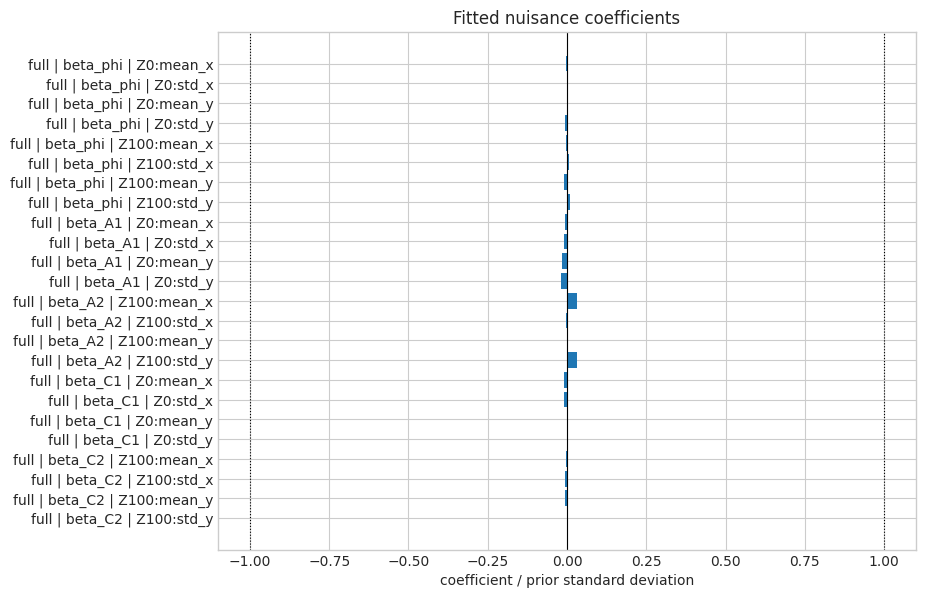

In [54]:
coefficient_rows = []
for model_name in feature_models:
    row = fit_rows[model_name]
    nuisance = MODEL_SPECS[model_name]
    groups = []
    if 'phase' in nuisance:
        groups.append(('beta_phi', tuple(f'Z0:{x}' for x in names_z0) + tuple(f'Z100:{x}' for x in names_z100), BETA_PHI_PRIOR_STD))
    if 'offset' in nuisance:
        groups += [('beta_A1', tuple(f'Z0:{x}' for x in names_z0), BETA_A_PRIOR_STD),
                   ('beta_A2', tuple(f'Z100:{x}' for x in names_z100), BETA_A_PRIOR_STD)]
    if 'contrast' in nuisance:
        groups += [('beta_C1', tuple(f'Z0:{x}' for x in names_z0), BETA_C_PRIOR_STD),
                   ('beta_C2', tuple(f'Z100:{x}' for x in names_z100), BETA_C_PRIOR_STD)]
    for block, labels, prior_std in groups:
        values = beta(row, block, len(labels))
        for label, value in zip(labels, values):
            coefficient_rows.append(dict(model=model_name, block=block, feature=label,
                                         coefficient=value, prior_std=prior_std,
                                         prior_units=value/prior_std))
coefficients = pd.DataFrame(coefficient_rows)
display(coefficients)
if len(coefficients):
    labels = coefficients['model'] + ' | ' + coefficients['block'] + ' | ' + coefficients['feature']
    fig, ax = plt.subplots(figsize=(9, max(3, 0.28*len(coefficients))))
    ax.barh(np.arange(len(coefficients)), coefficients['prior_units'])
    ax.set_yticks(np.arange(len(coefficients)), labels)
    ax.axvline(0, color='k', lw=0.8)
    ax.axvline(1, color='k', ls=':', lw=0.8)
    ax.axvline(-1, color='k', ls=':', lw=0.8)
    ax.set(xlabel='coefficient / prior standard deviation', title='Fitted nuisance coefficients')
    ax.invert_yaxis()


## Truth-assisted residuals and shot noise

Because this is simulated data, the stored Z0 laser phase is available. The marginalized likelihood leaves one constant common response-phase gauge unidentified, so the code estimates that single angle from Z0 and then uses the same angle to predict Z100. This turns each fitted model into a per-shot probability prediction without fitting away differential residuals. The shaded bands are the binomial $1\sigma$ shot-noise expectation. A useful model should reduce coherent/excess residual structure without merely driving parameters against physical boundaries.


In [55]:
theta_stored = np.asarray(Z0.phi0, dtype=float)

def common_gauge_angle(terms, n_grid=1440):
    """Recover the common response-phase gauge from Z0 only.

    The atom-count likelihood marginalizes theta_i and therefore does not fit
    this angle. The simulator's stored laser phase and the cosine response
    convention differ by one constant gauge angle.
    """
    gamma = np.linspace(0, 2*np.pi, n_grid, endpoint=False)
    p = terms['A0'][:, None] + 0.5*terms['C0'][:, None]*np.cos(theta_stored[:, None] + gamma[None, :])
    valid = np.all((p > 0) & (p < 1), axis=0)
    ll = np.full(n_grid, -np.inf)
    ll[valid] = np.sum(
        n0[:, None]*np.log(p[:, valid]) + (N0-n0)[:, None]*np.log1p(-p[:, valid]), axis=0
    )
    return gamma[int(np.argmax(ll))]

def predictions_and_residuals(model_name, row):
    terms = reconstruct(row, model_name)
    gamma = common_gauge_angle(terms)
    theta = theta_stored + gamma
    p0 = terms['A0'] + 0.5*terms['C0']*np.cos(theta)
    p100 = terms['A100'] + 0.5*terms['C100']*np.cos(
        theta + terms['dphi_signal'] + terms['dpsi']
    )
    p0 = np.clip(p0, 1e-12, 1-1e-12)
    p100 = np.clip(p100, 1e-12, 1-1e-12)
    r0, r100 = gf0-p0, gf100-p100
    sig0 = np.sqrt(p0*(1-p0)/N0)
    sig100 = np.sqrt(p100*(1-p100)/N100)
    return p0, p100, r0, r100, sig0, sig100

residual_table = {}
for name, row in fit_rows.items():
    _, _, r0, r100, sig0, sig100 = predictions_and_residuals(name, row)
    residual_table[name] = {
        'Z0 RMS / RMS shot noise': np.sqrt(np.mean(r0**2)) / np.sqrt(np.mean(sig0**2)),
        'Z100 RMS / RMS shot noise': np.sqrt(np.mean(r100**2)) / np.sqrt(np.mean(sig100**2)),
        'Z0 normalized residual std': np.std(r0/sig0),
        'Z100 normalized residual std': np.std(r100/sig100),
        'corr residuals Z0,Z100': np.corrcoef(r0/sig0, r100/sig100)[0, 1],
    }
residual_summary = pd.DataFrame(residual_table).T
display(residual_summary)


,Z0 RMS / RMS shot noise,Z100 RMS / RMS shot noise,Z0 normalized residual std,Z100 normalized residual std,"corr residuals Z0,Z100"
count-only,2.775635,2.268601,3.401720,3.103824,-0.144159
full,2.775450,4.593820,3.101135,4.060005,-0.256190


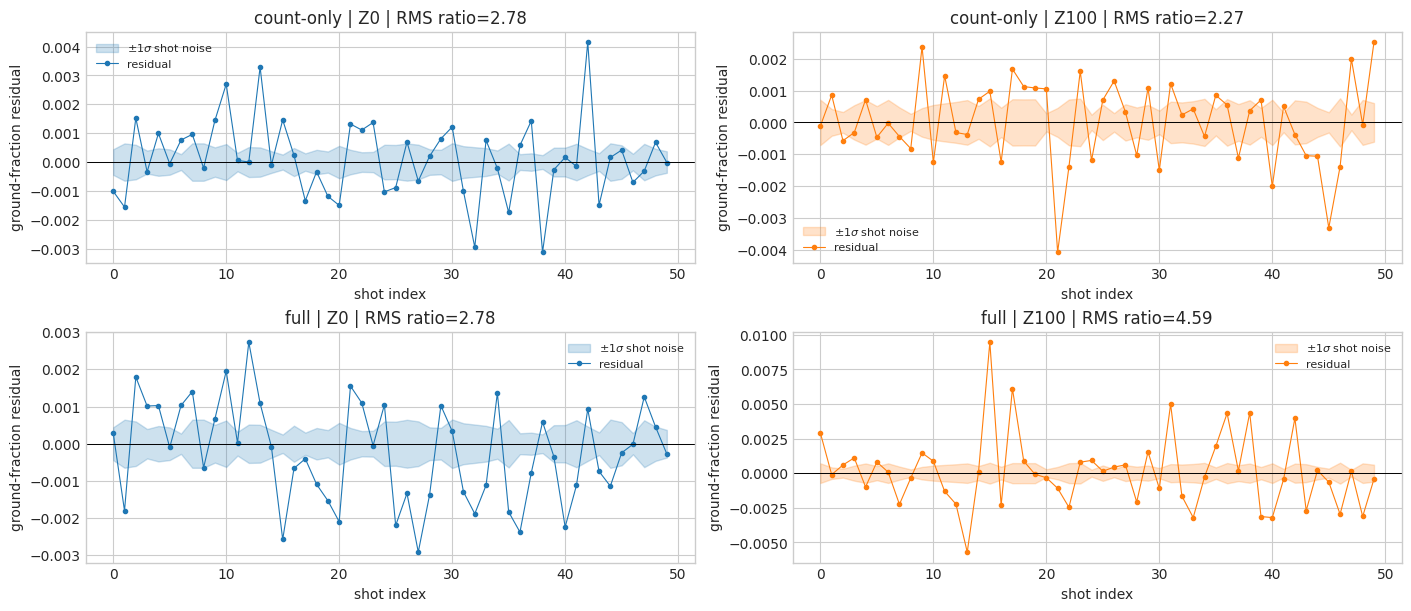

In [56]:
models = list(fit_rows)
fig, axes = plt.subplots(len(models), 2, figsize=(14, 3.0*len(models)), squeeze=False, constrained_layout=True)
for i, name in enumerate(models):
    _, _, r0, r100, sig0, sig100 = predictions_and_residuals(name, fit_rows[name])
    for ax, resid, sigma, site, color in [
        (axes[i, 0], r0, sig0, 'Z0', 'C0'),
        (axes[i, 1], r100, sig100, 'Z100', 'C1'),
    ]:
        ax.fill_between(t, -sigma, sigma, color=color, alpha=0.22, label=r'$\pm1\sigma$ shot noise')
        ax.plot(t, resid, 'o-', color=color, ms=3, lw=0.8, label='residual')
        ax.axhline(0, color='k', lw=0.7)
        ratio = np.sqrt(np.mean(resid**2))/np.sqrt(np.mean(sigma**2))
        ax.set(title=f'{name} | {site} | RMS ratio={ratio:.2f}', xlabel='shot index', ylabel='ground-fraction residual')
        ax.legend(fontsize=8)


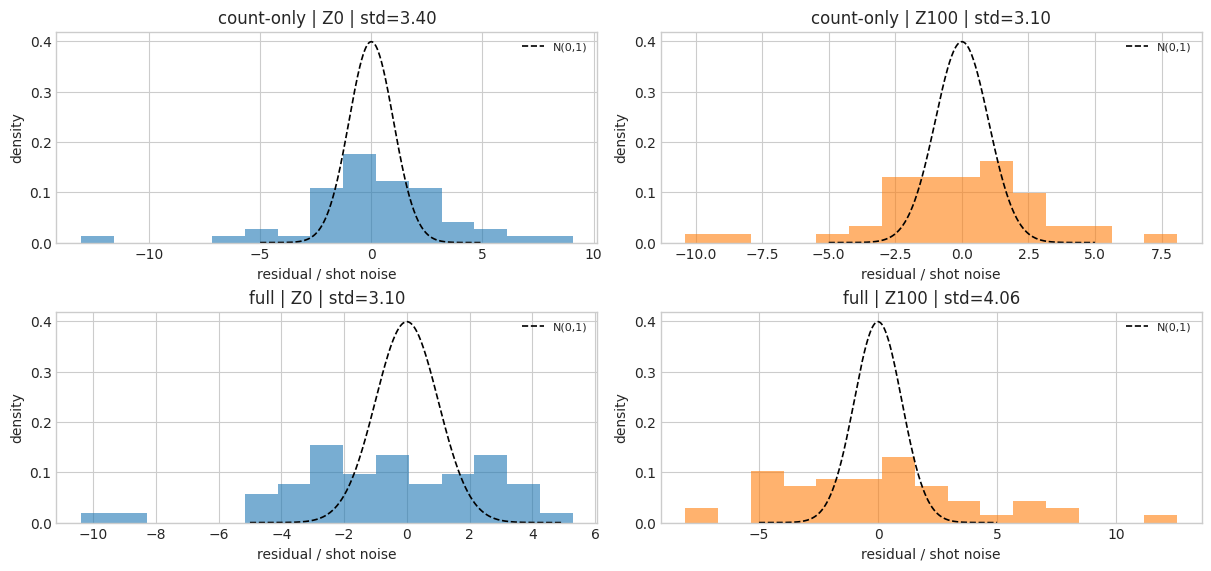

In [57]:
fig, axes = plt.subplots(len(models), 2, figsize=(12, 2.8*len(models)), squeeze=False, constrained_layout=True)
xgrid = np.linspace(-5, 5, 400)
normal = np.exp(-xgrid**2/2)/np.sqrt(2*np.pi)
for i, name in enumerate(models):
    _, _, r0, r100, sig0, sig100 = predictions_and_residuals(name, fit_rows[name])
    for ax, z, site, color in [(axes[i,0], r0/sig0, 'Z0', 'C0'), (axes[i,1], r100/sig100, 'Z100', 'C1')]:
        ax.hist(z, bins=15, density=True, alpha=0.6, color=color)
        ax.plot(xgrid, normal, 'k--', lw=1.2, label='N(0,1)')
        ax.set(title=f'{name} | {site} | std={np.std(z):.2f}', xlabel='residual / shot noise', ylabel='density')
        ax.legend(fontsize=8)


In [58]:
# Which selected summaries still correlate with the normalized residuals?
corr_rows = []
for name, row in fit_rows.items():
    _, _, r0, r100, sig0, sig100 = predictions_and_residuals(name, row)
    for feature_name in feature_frame:
        corr_rows.append({
            'model': name,
            'feature': feature_name,
            'corr with Z0 residual': np.corrcoef(feature_frame[feature_name], r0/sig0)[0,1],
            'corr with Z100 residual': np.corrcoef(feature_frame[feature_name], r100/sig100)[0,1],
        })
residual_feature_corr = pd.DataFrame(corr_rows)
display(residual_feature_corr.pivot(index=['model','feature'], columns=[], values=['corr with Z0 residual','corr with Z100 residual']).round(3))


corr with Z0 residual  corr with Z100 residual
model      feature                                                    
count-only Z0:mean_x                    0.055                   -0.077
           Z0:std_x                     0.153                   -0.123
           Z0:mean_y                   -0.085                   -0.032
           Z0:std_y                    -0.402                    0.074
           Z100:mean_x                 -0.231                    0.203
           Z100:std_x                   0.075                   -0.357
           Z100:mean_y                  0.229                    0.045
           Z100:std_y                  -0.045                    0.249
full       Z0:mean_x                   -0.042                   -0.096
           Z0:std_x                    -0.010                    0.018
           Z0:mean_y                    0.343                   -0.076
           Z0:std_y                     0.269                    0.104
           Z100:mean_x                  0.015                   -0.095
           Z100:std_x                  -0.077                    0.038
           Z100:mean_y                 -0.078                   -0.083
           Z100:std_y                  -0.014                   -0.158

## Local likelihood slices in the science parameters

These are conditional slices: all nuisance parameters remain fixed while amplitude or phase is varied. They do not replace a profile likelihood, but they quickly reveal whether the returned point sits near a smooth local maximum, on a flat direction, or away from the best nearby value. The feature models include the same Gaussian beta penalty used during fitting; it is constant along these particular slices.


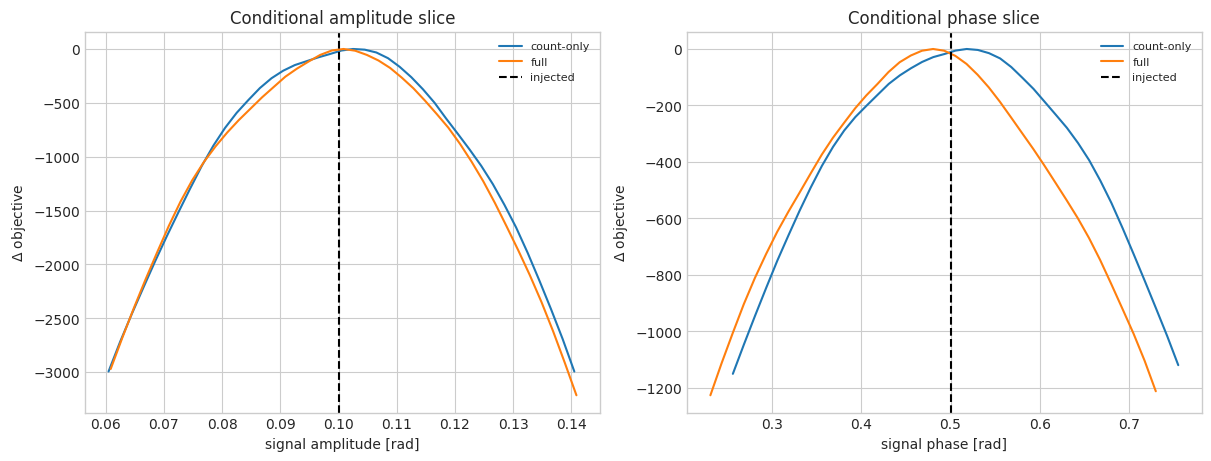

In [59]:
ev_count = LikelihoodEvaluator(n0, n100, N0, N100, use_gpu=USE_GPU, ntheta=NTHETA)
ev_feature = FeatureConditionedLikelihoodEvaluator(
    n0, n100, N0, N100, features_z0, features_z100,
    use_gpu=USE_GPU, ntheta=NTHETA,
    feature_mean_z0=artifact_z0['feature_mean'], feature_scale_z0=artifact_z0['feature_scale'],
    feature_mean_z100=artifact_z100['feature_mean'], feature_scale_z100=artifact_z100['feature_scale'],
)

def objective_at(model_name, row, amp, phase):
    As = amp*np.cos(phase)
    Ac = amp*np.sin(phase)
    if As < 0:
        return np.nan
    if MODEL_SPECS[model_name] is None:
        return ev_count.signal_ll(row['A1'], row['A2'], row['C1'], row['C2'], row['phi0'], As, Ac,
                                  f=FREQUENCY, coarse=True)
    nuisance = MODEL_SPECS[model_name]
    kwargs = {}
    if 'phase' in nuisance:
        kwargs['beta_phi'] = beta(row, 'beta_phi', len(names_z0)+len(names_z100))
    if 'offset' in nuisance:
        kwargs['beta_A1'] = beta(row, 'beta_A1', len(names_z0))
        kwargs['beta_A2'] = beta(row, 'beta_A2', len(names_z100))
    if 'contrast' in nuisance:
        kwargs['beta_C1'] = beta(row, 'beta_C1', len(names_z0))
        kwargs['beta_C2'] = beta(row, 'beta_C2', len(names_z100))
    ll = ev_feature.signal_ll_feature(row['A1'], row['A2'], row['C1'], row['C2'], row['phi0'], As, Ac,
                                      f=FREQUENCY, coarse=True, **kwargs)
    return ll - float(row.get('beta_penalty', 0.0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for name, row in fit_rows.items():
    amp_grid = np.linspace(max(0, float(row['amp'])-0.04), float(row['amp'])+0.04, 41)
    phase_grid = np.linspace(float(row['phase'])-0.25, float(row['phase'])+0.25, 41)
    amp_obj = np.array([objective_at(name, row, a, float(row['phase'])) for a in amp_grid])
    phase_obj = np.array([objective_at(name, row, float(row['amp']), p) for p in phase_grid])
    axes[0].plot(amp_grid, amp_obj-np.nanmax(amp_obj), label=name)
    axes[1].plot(phase_grid, phase_obj-np.nanmax(phase_obj), label=name)
axes[0].axvline(SIGNAL_AMP, color='k', ls='--', label='injected')
axes[1].axvline(SIGNAL_PHASE, color='k', ls='--', label='injected')
axes[0].set(xlabel='signal amplitude [rad]', ylabel=r'$\Delta$ objective', title='Conditional amplitude slice')
axes[1].set(xlabel='signal phase [rad]', ylabel=r'$\Delta$ objective', title='Conditional phase slice')
for ax in axes:
    ax.legend(fontsize=8)


## Reading the diagnosis

- First fit `phase`. It is the smallest physically motivated extension and uses both Z0 and Z100 summaries in $\delta\psi_i$.
- Add `offset` or `contrast` separately before fitting `full`. This reveals which block improves residuals and which merely creates flat directions.
- Treat `converged=False` alongside the local slices. A smooth maximum with stable science parameters can indicate overly strict Nelder-Mead stopping tolerances; a drifting/flat slice indicates genuine weak identification.
- Watch the minimum physical margin. Near-zero margins make the current hard invalid-probability objective discontinuous to the optimizer.
- Compare normalized residual widths and residual-feature correlations. Useful summaries should reduce both without requiring beta coefficients many prior standard deviations from zero.
- Repeat with `NTHETA=None` and `FAST=False` only after choosing a defensible nuisance model and feature set.
